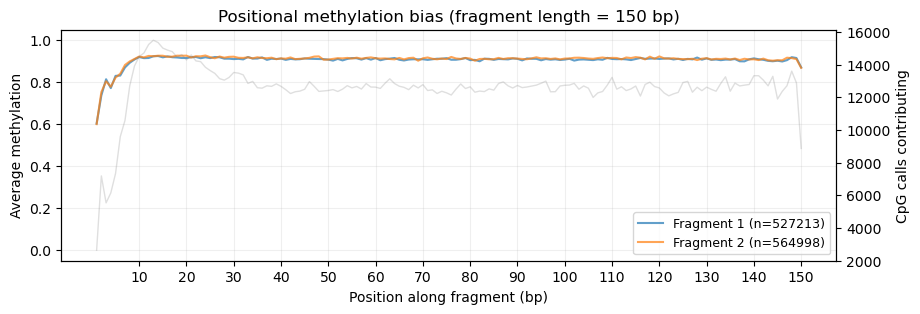

In [2]:
import gzip
import numpy as np
import matplotlib.pyplot as plt

pairs_path = '../results/20250612_hct116/pairs/HCT116_Meth_MicroC.meth.pairs.gz'
FRAG_LEN = 150  # only use fragments with this length
MAX_DATA_LINES = 10_000_000  # only use the first N non-header data lines from the input file

def _accumulate_meth_string(meth: str, sums: np.ndarray, counts: np.ndarray) -> bool:
    """Update sums/counts for a single methylation string.

    Encoding: '1' methylated CpG, '0' unmethylated CpG, '-' not a CpG site.
    Any other characters (e.g. '.') are treated as missing/ignored.
"""
    if len(meth) != FRAG_LEN:
        return False
    for i, ch in enumerate(meth):
        if ch == '1':
            sums[i] += 1
            counts[i] += 1
        elif ch == '0':
            counts[i] += 1
    return True

sums1 = np.zeros(FRAG_LEN, dtype=np.int64)
cnts1 = np.zeros(FRAG_LEN, dtype=np.int64)
sums2 = np.zeros(FRAG_LEN, dtype=np.int64)
cnts2 = np.zeros(FRAG_LEN, dtype=np.int64)
n_frag1 = 0
n_frag2 = 0

with gzip.open(pairs_path, 'rt') as fh:
    cols = None
    idx = None
    n_data_lines = 0
    for line in fh:
        if line.startswith('#columns:'):
            cols = line.rstrip('\n').split('\t')[1:]
            idx = {c: i for i, c in enumerate(cols)}
            if 'meth1' not in idx or 'meth2' not in idx:
                raise ValueError('Expected meth1/meth2 columns in #columns header')
            continue
        if line.startswith('#') or not line.strip():
            continue
        n_data_lines += 1
        if n_data_lines > MAX_DATA_LINES:
            break
        parts = line.rstrip('\n').split('\t')
        if _accumulate_meth_string(parts[idx['meth1']], sums1, cnts1):
            n_frag1 += 1
        if _accumulate_meth_string(parts[idx['meth2']], sums2, cnts2):
            n_frag2 += 1

avg1 = sums1 / np.where(cnts1 == 0, np.nan, cnts1)
avg2 = sums2 / np.where(cnts2 == 0, np.nan, cnts2)
avg_all = (sums1 + sums2) / np.where((cnts1 + cnts2) == 0, np.nan, (cnts1 + cnts2))

pos = np.arange(1, FRAG_LEN + 1)

fig, ax = plt.subplots(figsize=(10, 3))
#ax.plot(pos, avg_all, color='black', lw=2, label=f'meth1+meth2 (n={n_frag1+n_frag2} fragments)')
ax.plot(pos, avg1, alpha=0.7, label=f'Fragment 1 (n={n_frag1})')
ax.plot(pos, avg2, alpha=0.7, label=f'Fragment 2 (n={n_frag2})')
ax.set_xlabel("Position along fragment (bp)")
ax.set_xticks(np.arange(10, FRAG_LEN + 1, 10))
ax.set_ylabel('Average methylation')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.2)
ax.legend(loc='lower right', fontsize=9)

ax2 = ax.twinx()
ax2.plot(pos, cnts1 + cnts2, color='gray', alpha=0.25, lw=1, label='CpG calls (denominator)')
ax2.set_ylabel('CpG calls contributing')

ax.set_title(f'Positional methylation bias (fragment length = {FRAG_LEN} bp)')
plt.show()
